<a href="https://colab.research.google.com/github/profliuhao/CSIT599/blob/main/CSIT599_module6_exercise_deep_reinforcement_learning_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSIT 599 Deep Learning
# Module 12-13: Reinforcement Learning


# 1: Setup and Imports

In [1]:
# Cell 1: Setup and Imports
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical

import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import animation
from IPython.display import HTML
import seaborn as sns
from collections import deque, defaultdict
import random
from tqdm import tqdm
import time
import warnings
warnings.filterwarnings('ignore')

# Set style and random seeds
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Install required packages
# !pip install gym[classic_control]
# !pip install gymnasium
!pip install stable-baselines3  # For comparison

# Create directories for results
import os
os.makedirs('results/rl', exist_ok=True)

Using device: cuda
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 19.4 MB/s eta 0:00:00


# 2: Learning Objectives

By the end of this exercise, you will:
1. Implement Q-learning on a custom GridWorld environment
2. Build Deep Q-Network (DQN) for CartPole with experience replay
3. Implement policy gradient methods for continuous control
4. Implement Actor-Critic methods for continuous control
5. Visualize value functions and policies


# 3: Custom GridWorld Environment

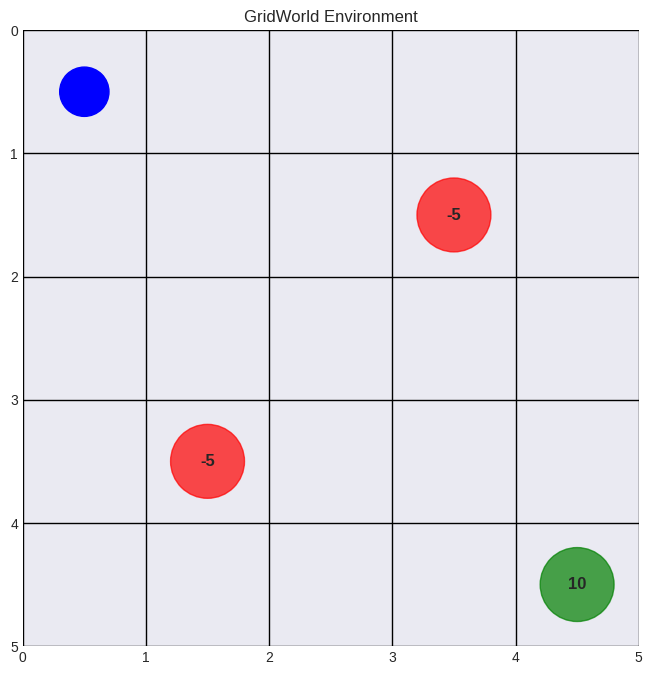

In [2]:
# Cell 3: Custom GridWorld Environment

class GridWorld:
    """
    Custom GridWorld environment for understanding RL basics
    """

    def __init__(self, size=5, obstacles=None, rewards=None):
        self.size = size
        self.obstacles = obstacles or []
        self.rewards = rewards or {}

        # Default setup if not specified
        if not self.rewards:
            self.rewards = {(size-1, size-1): 10}  # Goal at bottom-right

        # Add some negative rewards (pits)
        if size >= 5:
            self.rewards[(1, 3)] = -5
            self.rewards[(3, 1)] = -5

        self.reset()

    def reset(self):
        """Reset environment to starting state"""
        self.agent_pos = [0, 0]  # Start at top-left
        return self._get_state()

    def _get_state(self):
        """Get current state as tuple"""
        return tuple(self.agent_pos)

    def step(self, action):
        """
        Take action in environment
        Actions: 0=up, 1=right, 2=down, 3=left
        """
        # Movement vectors
        moves = [(-1, 0), (0, 1), (1, 0), (0, -1)]

        # Calculate new position
        new_pos = [
            self.agent_pos[0] + moves[action][0],
            self.agent_pos[1] + moves[action][1]
        ]

        # Check boundaries
        if (0 <= new_pos[0] < self.size and
            0 <= new_pos[1] < self.size and
            tuple(new_pos) not in self.obstacles):
            self.agent_pos = new_pos

        # Get reward
        state = self._get_state()
        reward = self.rewards.get(state, -0.1)  # Small penalty for each step

        # Check if done
        done = state == (self.size-1, self.size-1) or reward < -1

        return state, reward, done, {}

    def render(self, q_values=None, policy=None, ax=None):
        """Render the grid world"""
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 8))

        # Clear previous plot
        ax.clear()

        # Draw grid
        for i in range(self.size + 1):
            ax.axhline(i, color='black', linewidth=1)
            ax.axvline(i, color='black', linewidth=1)

        # Draw obstacles
        for obs in self.obstacles:
            rect = patches.Rectangle((obs[1], obs[0]), 1, 1,
                                   linewidth=1, edgecolor='black',
                                   facecolor='gray')
            ax.add_patch(rect)

        # Draw rewards
        for pos, reward in self.rewards.items():
            color = 'green' if reward > 0 else 'red'
            circle = patches.Circle((pos[1] + 0.5, pos[0] + 0.5), 0.3,
                                  color=color, alpha=0.7)
            ax.add_patch(circle)
            ax.text(pos[1] + 0.5, pos[0] + 0.5, f'{reward}',
                   ha='center', va='center', fontsize=12, fontweight='bold')

        # Draw agent
        agent_circle = patches.Circle((self.agent_pos[1] + 0.5, self.agent_pos[0] + 0.5),
                                    0.2, color='blue')
        ax.add_patch(agent_circle)

        # Draw Q-values or policy
        if q_values is not None:
            self._draw_q_values(ax, q_values)
        elif policy is not None:
            self._draw_policy(ax, policy)

        ax.set_xlim(0, self.size)
        ax.set_ylim(0, self.size)
        ax.set_aspect('equal')
        ax.invert_yaxis()
        ax.set_title('GridWorld Environment')

        return ax

    def _draw_q_values(self, ax, q_values):
        """Draw Q-values as arrows"""
        actions = ['↑', '→', '↓', '←']
        offsets = [(-0.25, 0), (0, 0.25), (0.25, 0), (0, -0.25)]

        for i in range(self.size):
            for j in range(self.size):
                state = (i, j)
                if state in q_values and state not in self.obstacles:
                    for a, (action_symbol, offset) in enumerate(zip(actions, offsets)):
                        q_val = q_values[state][a]
                        # Normalize Q-value for visualization
                        alpha = min(abs(q_val) / 10, 1.0)
                        color = 'green' if q_val > 0 else 'red'
                        ax.text(j + 0.5 + offset[1], i + 0.5 + offset[0],
                               action_symbol, ha='center', va='center',
                               fontsize=14, color=color, alpha=alpha,
                               fontweight='bold')

    def _draw_policy(self, ax, policy):
        """Draw policy as arrows"""
        actions = ['↑', '→', '↓', '←']

        for i in range(self.size):
            for j in range(self.size):
                state = (i, j)
                if state in policy and state not in self.obstacles:
                    action = policy[state]
                    ax.text(j + 0.5, i + 0.5, actions[action],
                           ha='center', va='center', fontsize=20,
                           fontweight='bold', color='darkblue')

# Create and visualize GridWorld
env = GridWorld(size=5)
env.render()
plt.show()

# 4: Q-Learning Implementation

Training Q-Learning Agent on GridWorld...
Episode 200: Avg Reward = 7.02


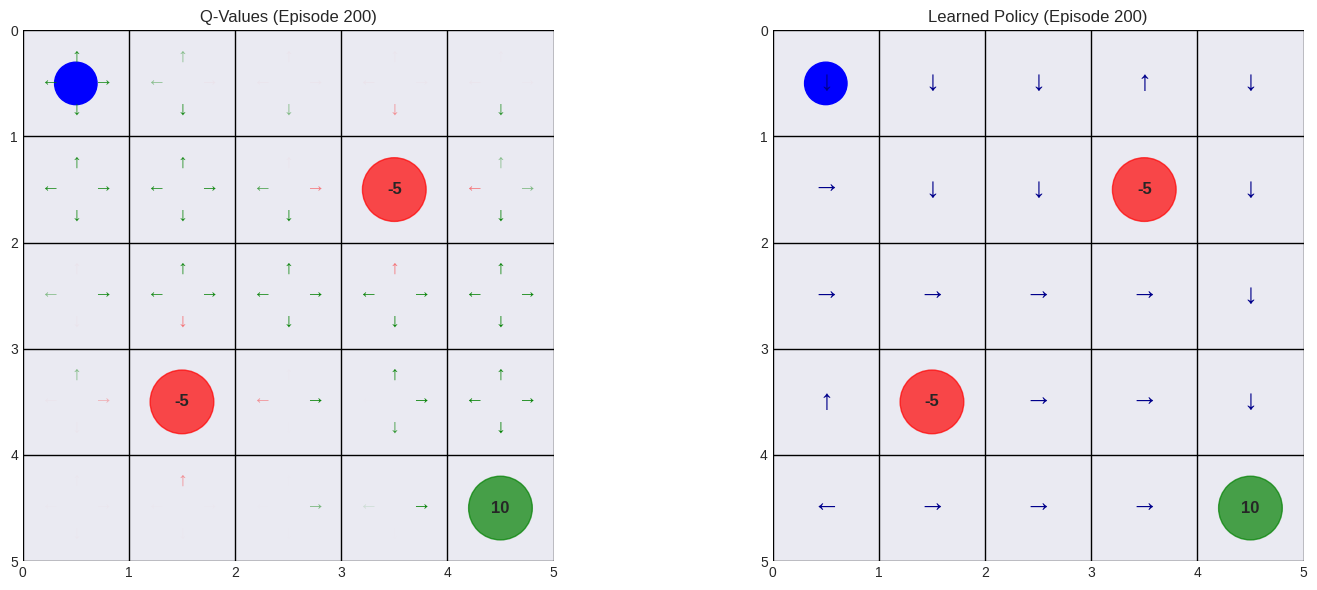

Episode 400: Avg Reward = 7.77


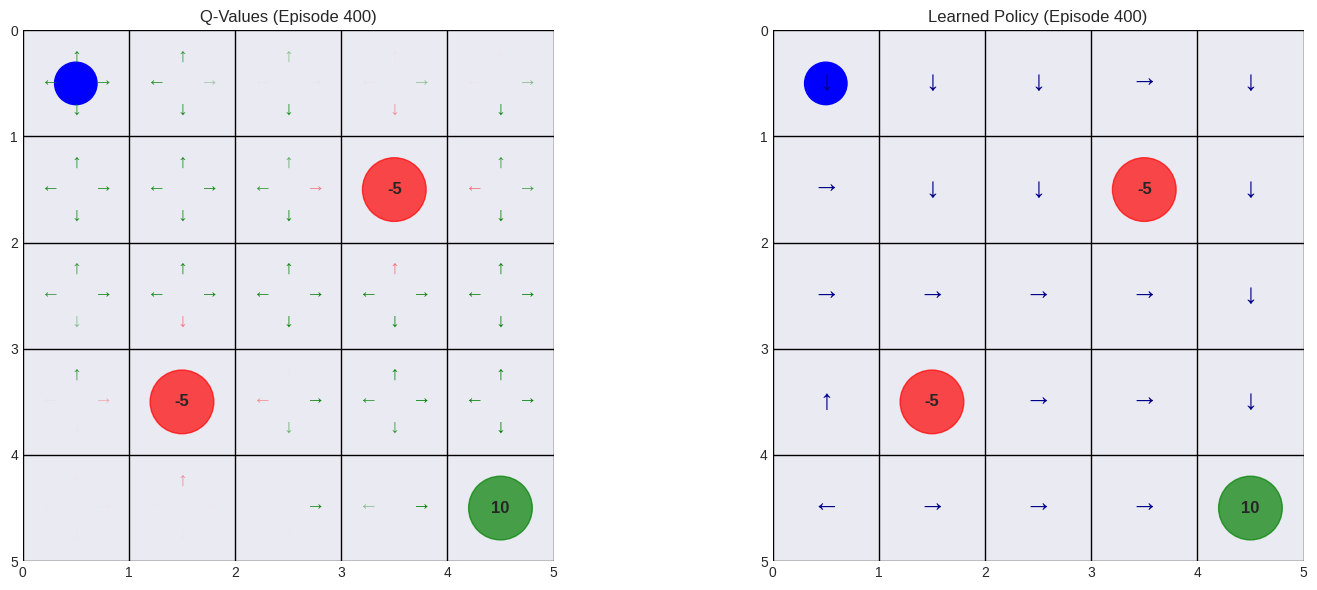

Episode 600: Avg Reward = 6.18


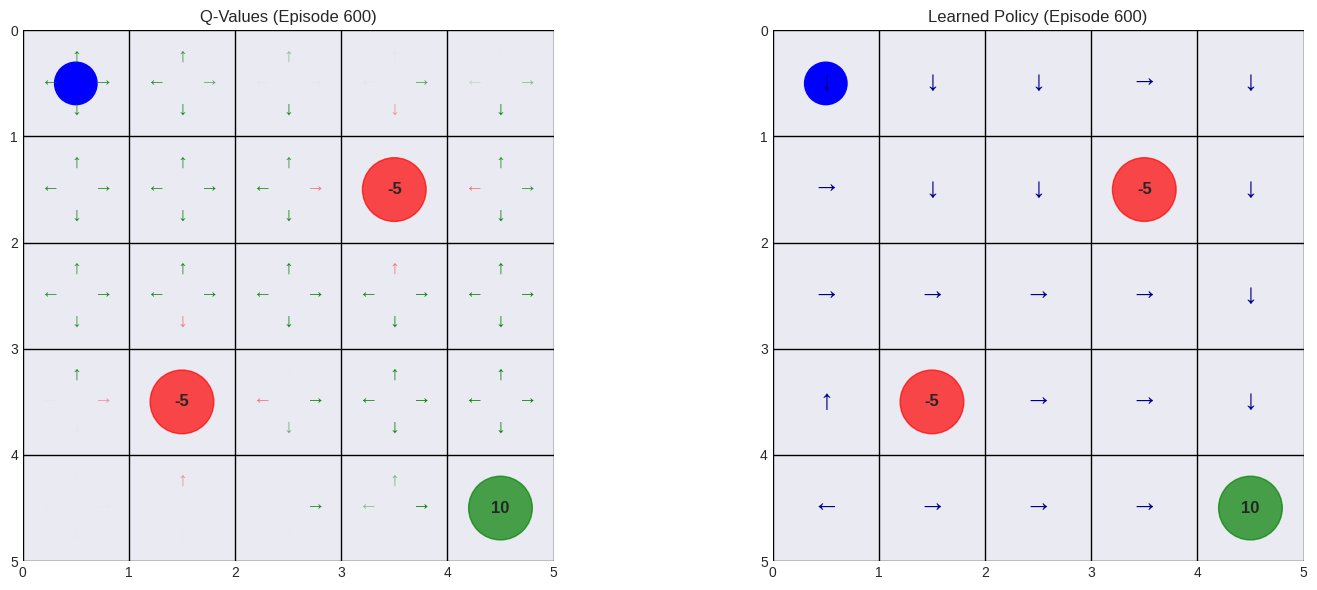

Episode 800: Avg Reward = 6.78


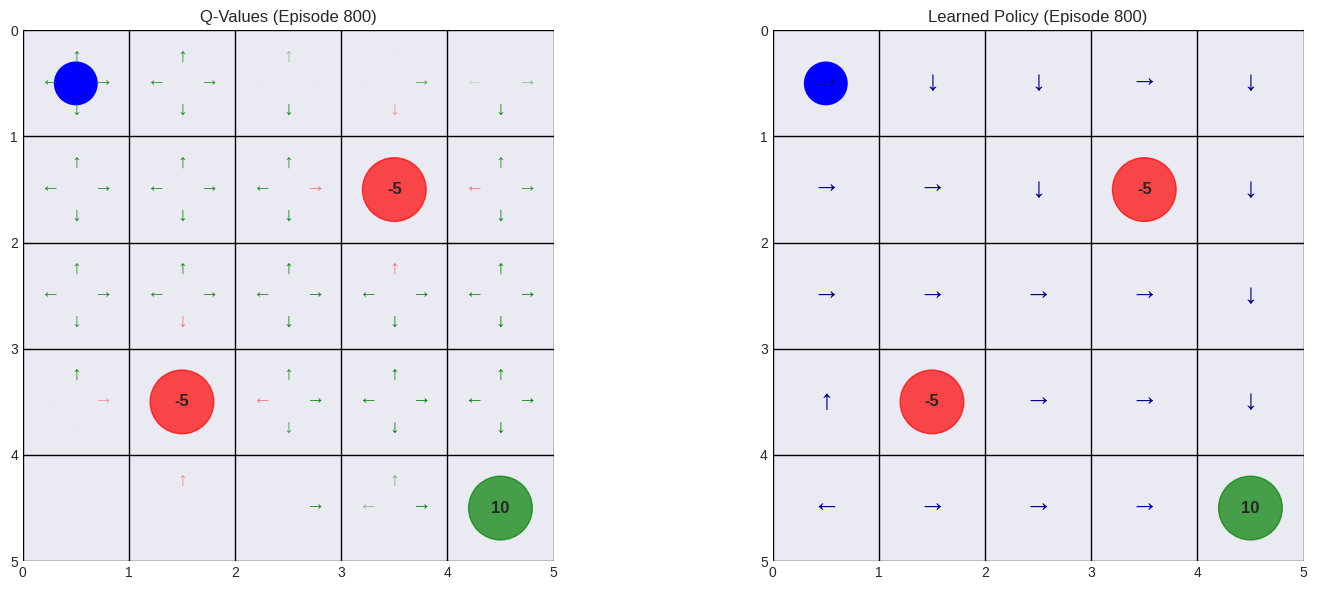

Episode 1000: Avg Reward = 7.12


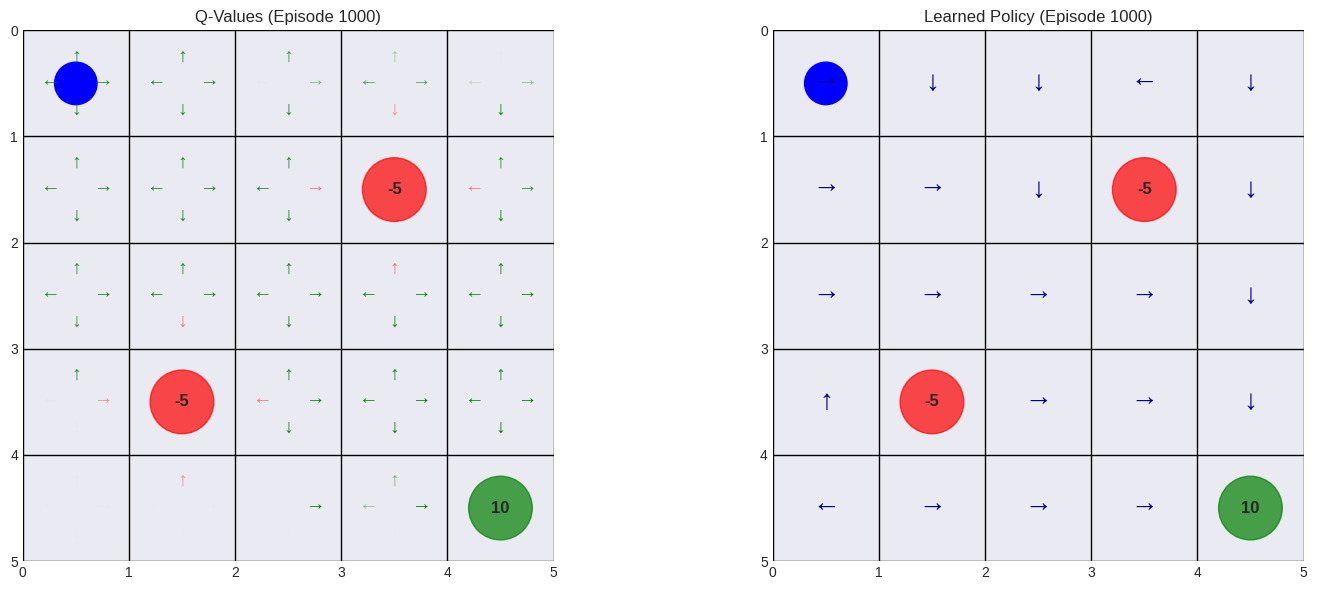

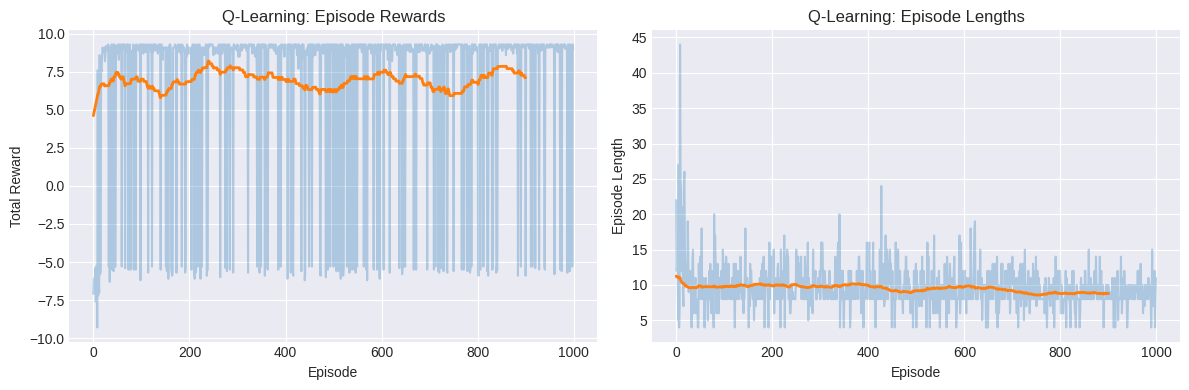

In [3]:
# Cell 4: Q-Learning Implementation

class QLearningAgent:
    """Q-Learning agent for tabular environments"""

    def __init__(self, n_states, n_actions, learning_rate=0.1,
                 discount_factor=0.99, epsilon=0.1):
        self.n_states = n_states
        self.n_actions = n_actions
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon

        # Initialize Q-table
        self.q_table = defaultdict(lambda: np.zeros(n_actions))

    def get_action(self, state, training=True):
        """Epsilon-greedy action selection"""
        if training and random.random() < self.epsilon:
            return random.randint(0, self.n_actions - 1)
        else:
            q_values = self.q_table[state]
            # Break ties randomly
            max_q = np.max(q_values)
            actions_with_max_q = np.where(q_values == max_q)[0]
            return np.random.choice(actions_with_max_q)

    def update(self, state, action, reward, next_state, done):
        """Q-learning update rule"""
        current_q = self.q_table[state][action]

        if done:
            target = reward
        else:
            next_max_q = np.max(self.q_table[next_state])
            target = reward + self.gamma * next_max_q

        # Q-learning update
        self.q_table[state][action] = current_q + self.lr * (target - current_q)

    def get_policy(self):
        """Extract greedy policy from Q-table"""
        policy = {}
        for state, q_values in self.q_table.items():
            policy[state] = np.argmax(q_values)
        return policy

def train_q_learning(env, agent, n_episodes=1000, visualize_every=200):
    """Train Q-learning agent"""
    episode_rewards = []
    episode_lengths = []

    for episode in range(n_episodes):
        state = env.reset()
        total_reward = 0
        steps = 0

        while True:
            action = agent.get_action(state)
            next_state, reward, done, _ = env.step(action)

            agent.update(state, action, reward, next_state, done)

            total_reward += reward
            steps += 1
            state = next_state

            if done or steps > 100:
                break

        episode_rewards.append(total_reward)
        episode_lengths.append(steps)

        # Decay epsilon
        if episode % 100 == 0:
            agent.epsilon = max(0.01, agent.epsilon * 0.95)

        # Visualize progress
        if (episode + 1) % visualize_every == 0:
            print(f"Episode {episode + 1}: Avg Reward = {np.mean(episode_rewards[-100:]):.2f}")

            # Show learned Q-values and policy
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

            env.reset()
            env.render(q_values=dict(agent.q_table), ax=ax1)
            ax1.set_title(f'Q-Values (Episode {episode + 1})')

            policy = agent.get_policy()
            env.render(policy=policy, ax=ax2)
            ax2.set_title(f'Learned Policy (Episode {episode + 1})')

            plt.tight_layout()
            plt.show()

    return episode_rewards, episode_lengths

# Train Q-learning agent
print("Training Q-Learning Agent on GridWorld...")
q_agent = QLearningAgent(n_states=25, n_actions=4, learning_rate=0.5, epsilon=0.3)
q_rewards, q_lengths = train_q_learning(env, q_agent, n_episodes=1000)

# Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(q_rewards, alpha=0.3)
plt.plot(np.convolve(q_rewards, np.ones(100)/100, mode='valid'), linewidth=2)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Q-Learning: Episode Rewards')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(q_lengths, alpha=0.3)
plt.plot(np.convolve(q_lengths, np.ones(100)/100, mode='valid'), linewidth=2)
plt.xlabel('Episode')
plt.ylabel('Episode Length')
plt.title('Q-Learning: Episode Lengths')
plt.grid(True)

plt.tight_layout()
plt.show()

# 5: Value Iteration Visualization

Value iteration converged in 9 iterations


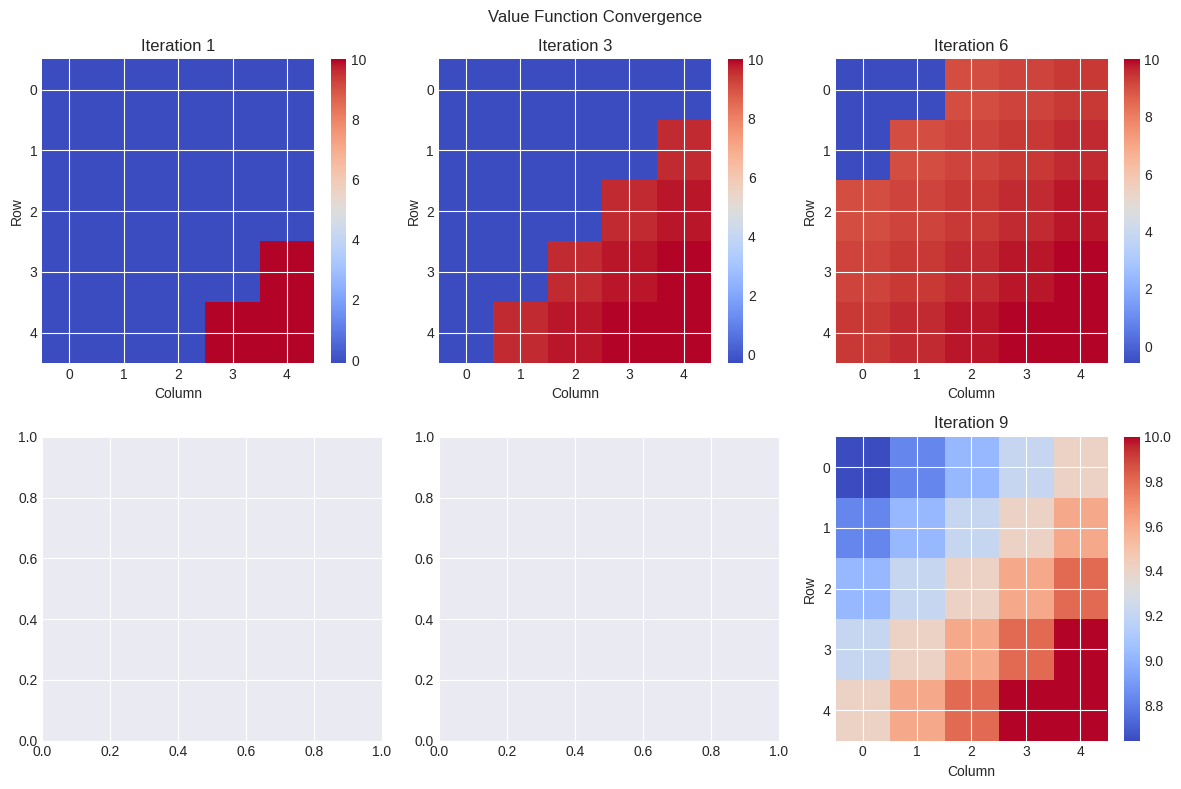

In [4]:
# Cell 5: Value Iteration Visualization

def value_iteration(env, gamma=0.99, theta=0.001):
    """
    Value iteration algorithm for comparison
    """
    # Initialize value function
    V = np.zeros((env.size, env.size))

    iterations = 0
    history = []

    while True:
        delta = 0
        V_new = np.copy(V)

        for i in range(env.size):
            for j in range(env.size):
                if (i, j) in env.obstacles:
                    continue

                state = (i, j)
                env.agent_pos = [i, j]

                # Calculate value for each action
                action_values = []
                for action in range(4):
                    # Simulate action
                    next_state, reward, done, _ = env.step(action)
                    env.agent_pos = [i, j]  # Reset position

                    if done:
                        value = reward
                    else:
                        value = reward + gamma * V[next_state[0], next_state[1]]

                    action_values.append(value)

                # Update value function
                V_new[i, j] = max(action_values)
                delta = max(delta, abs(V_new[i, j] - V[i, j]))

        V = V_new
        iterations += 1
        history.append(np.copy(V))

        if delta < theta:
            break

    print(f"Value iteration converged in {iterations} iterations")
    return V, history

# Run value iteration
V_optimal, V_history = value_iteration(env)

# Visualize value function convergence
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

steps_to_show = [0, 2, 5, 10, 20, len(V_history)-1]

for idx, step in enumerate(steps_to_show):
    if step < len(V_history):
        ax = axes[idx]
        im = ax.imshow(V_history[step], cmap='coolwarm', aspect='auto')
        ax.set_title(f'Iteration {step + 1}')
        ax.set_xlabel('Column')
        ax.set_ylabel('Row')
        plt.colorbar(im, ax=ax)

plt.suptitle('Value Function Convergence')
plt.tight_layout()
plt.show()

# 6: Deep Q-Network (DQN) Implementation

In [5]:
# Cell 6: Deep Q-Network (DQN) Implementation

class DQN(nn.Module):
    """Deep Q-Network"""

    def __init__(self, input_dim, output_dim, hidden_dim=128):
        super(DQN, self).__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class ReplayBuffer:
    """Experience replay buffer"""

    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*batch)

        return (torch.FloatTensor(state),
                torch.LongTensor(action),
                torch.FloatTensor(reward),
                torch.FloatTensor(next_state),
                torch.FloatTensor(done))

    def __len__(self):
        return len(self.buffer)

class DQNAgent:
    """DQN Agent with experience replay and target network"""

    def __init__(self, state_dim, action_dim, lr=0.001, gamma=0.99,
                 epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

        # Networks
        self.q_network = DQN(state_dim, action_dim).to(device)
        self.target_network = DQN(state_dim, action_dim).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())

        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.memory = ReplayBuffer()

    def get_action(self, state, training=True):
        """Epsilon-greedy action selection"""
        if training and random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)

        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            q_values = self.q_network(state_tensor)
            return q_values.argmax().item()

    def update(self, batch_size=32):
        """Update Q-network using experience replay"""
        if len(self.memory) < batch_size:
            return

        states, actions, rewards, next_states, dones = self.memory.sample(batch_size)
        states = states.to(device)
        actions = actions.to(device)
        rewards = rewards.to(device)
        next_states = next_states.to(device)
        dones = dones.to(device)

        # Current Q values
        current_q_values = self.q_network(states).gather(1, actions.unsqueeze(1))

        # Next Q values from target network
        with torch.no_grad():
            next_q_values = self.target_network(next_states).max(1)[0]
            target_q_values = rewards + (1 - dones) * self.gamma * next_q_values

        # Compute loss
        loss = F.mse_loss(current_q_values.squeeze(), target_q_values)

        # Optimize
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_target_network(self):
        """Copy weights from main network to target network"""
        self.target_network.load_state_dict(self.q_network.state_dict())

    def decay_epsilon(self):
        """Decay exploration rate"""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

# 7: Train DQN on CartPole

Training DQN on CartPole...
Episode 0, Average Score: 14.00, Epsilon: 0.995
Episode 100, Average Score: 34.91, Epsilon: 0.603
Episode 200, Average Score: 81.04, Epsilon: 0.365
Episode 300, Average Score: 91.06, Epsilon: 0.221

Environment solved in 380 episodes!


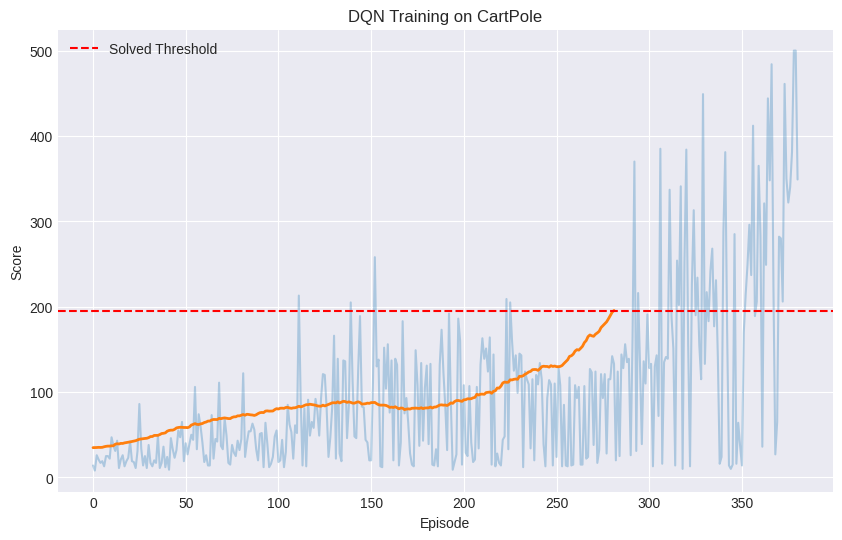

In [6]:
import gymnasium as gym # Ensure gymnasium is imported, it's already in cell 1 but good to be explicit for the environment

# Cell 7: Train DQN on CartPole

def train_dqn_cartpole(n_episodes=500):
    """Train DQN on CartPole environment"""

    # Create environment
    env = gym.make('CartPole-v1')
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    # Create agent
    agent = DQNAgent(state_dim, action_dim, lr=0.001)

    # Training metrics
    scores = []
    scores_window = deque(maxlen=100)

    for episode in range(n_episodes):
        state_tuple, info = env.reset() # env.reset() now returns state, info
        state = state_tuple # Extract state from tuple
        score = 0

        while True:
            # Select action
            action = agent.get_action(state)

            # Take action
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated # Combine terminated and truncated into done

            # Store experience
            agent.memory.push(state, action, reward, next_state, done)

            # Update network
            if len(agent.memory) > 32:
                agent.update()

            state = next_state
            score += reward

            if done:
                break

        scores.append(score)
        scores_window.append(score)
        agent.decay_epsilon()

        # Update target network
        if episode % 10 == 0:
            agent.update_target_network()

        # Print progress
        if episode % 100 == 0:
            print(f'Episode {episode}, Average Score: {np.mean(scores_window):.2f}, '
                  f'Epsilon: {agent.epsilon:.3f}')

        # Early stopping
        if np.mean(scores_window) >= 195.0:
            print(f'\nEnvironment solved in {episode} episodes!')
            break

    env.close()
    return agent, scores

# Train DQN
print("Training DQN on CartPole...")
dqn_agent, dqn_scores = train_dqn_cartpole(n_episodes=500)

# Plot training curve
plt.figure(figsize=(10, 6))
plt.plot(dqn_scores, alpha=0.3)
plt.plot(np.convolve(dqn_scores, np.ones(100)/100, mode='valid'), linewidth=2)
plt.axhline(y=195, color='r', linestyle='--', label='Solved Threshold')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.title('DQN Training on CartPole')
plt.legend()
plt.grid(True)
plt.show()

# 8: Visualize DQN Policy


In [7]:
# Cell 8: Visualize DQN Policy

def visualize_cartpole_policy(agent, n_episodes=3):
    """Visualize trained agent playing CartPole"""
    env = gym.make('CartPole-v1', render_mode='rgb_array') # Specify render_mode here

    for episode in range(n_episodes):
        state_tuple, info = env.reset() # env.reset() now returns state, info
        state = state_tuple # Extract state from tuple
        total_reward = 0
        frames = []

        print(f"\nEpisode {episode + 1}")

        while True:
            # Render and store frame
            frame = env.render() # mode='rgb_array' is no longer needed here
            frames.append(frame)

            # Get action from trained agent
            action = agent.get_action(state, training=False)

            # Take action
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated # Combine terminated and truncated
            total_reward += reward
            state = next_state

            if done:
                print(f"Total Reward: {total_reward}")
                break

        # Create animation
        if episode == 0:  # Only animate first episode
            fig, ax = plt.subplots(figsize=(6, 4))
            ax.axis('off')
            img = ax.imshow(frames[0])

            def update(frame):
                img.set_data(frame)
                return [img]

            anim = animation.FuncAnimation(fig, update, frames=frames[::2],
                                         interval=50, blit=True)
            plt.close()

            # Display animation
            display(HTML(anim.to_jshtml()))

    env.close()

# Visualize trained policy
print("Visualizing trained DQN policy...")
# Note: Animation display might not work in all environments
visualize_cartpole_policy(dqn_agent, n_episodes=3)

Visualizing trained DQN policy...

Episode 1
Total Reward: 500.0



Episode 2
Total Reward: 500.0

Episode 3
Total Reward: 500.0


# 9: Policy Gradient Methods


In [8]:
# Cell 9: Policy Gradient Methods

class PolicyNetwork(nn.Module):
    """Policy network for REINFORCE"""

    def __init__(self, input_dim, output_dim, hidden_dim=128):
        super(PolicyNetwork, self).__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return F.softmax(x, dim=-1)

class REINFORCE:
    """REINFORCE (Monte Carlo Policy Gradient) algorithm"""

    def __init__(self, state_dim, action_dim, lr=0.01, gamma=0.99):
        self.gamma = gamma

        self.policy = PolicyNetwork(state_dim, action_dim).to(device)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=lr)

        self.saved_log_probs = []
        self.rewards = []

    def get_action(self, state):
        """Sample action from policy"""
        state = torch.FloatTensor(state).unsqueeze(0).to(device)
        probs = self.policy(state)
        m = Categorical(probs)
        action = m.sample()
        self.saved_log_probs.append(m.log_prob(action))
        return action.item()

    def update(self):
        """Update policy using REINFORCE"""
        R = 0
        policy_loss = []
        returns = []

        # Calculate discounted returns
        for r in self.rewards[::-1]:
            R = r + self.gamma * R
            returns.insert(0, R)

        returns = torch.tensor(returns)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        # Calculate policy gradient
        for log_prob, R in zip(self.saved_log_probs, returns):
            policy_loss.append(-log_prob * R)

        # Update policy
        self.optimizer.zero_grad()
        policy_loss = torch.cat(policy_loss).sum()
        policy_loss.backward()
        self.optimizer.step()

        # Clear episode data
        self.saved_log_probs = []
        self.rewards = []

def train_reinforce(env_name='CartPole-v1', n_episodes=1000):
    """Train REINFORCE algorithm"""
    env = gym.make(env_name)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    agent = REINFORCE(state_dim, action_dim, lr=0.01)

    scores = []
    scores_window = deque(maxlen=100)

    for episode in range(n_episodes):
        state_tuple, info = env.reset() # Handle new gymnasium API
        state = state_tuple
        score = 0

        while True:
            action = agent.get_action(state)
            next_state_tuple, reward, terminated, truncated, info = env.step(action) # Handle new gymnasium API
            next_state = next_state_tuple
            done = terminated or truncated # Combine terminated and truncated

            agent.rewards.append(reward)
            state = next_state
            score += reward

            if done:
                break

        scores.append(score)
        scores_window.append(score)

        # Update policy
        agent.update()

        if episode % 100 == 0:
            print(f'Episode {episode}, Average Score: {np.mean(scores_window):.2f}')

        if np.mean(scores_window) >= 195.0:
            print(f'\nEnvironment solved in {episode} episodes!')
            break

    env.close()
    return agent, scores

# Train REINFORCE
print("\nTraining REINFORCE on CartPole...")
reinforce_agent, reinforce_scores = train_reinforce(n_episodes=1000)


Training REINFORCE on CartPole...
Episode 0, Average Score: 16.00
Episode 100, Average Score: 9.62
Episode 200, Average Score: 10.55
Episode 300, Average Score: 9.28
Episode 400, Average Score: 9.45
Episode 500, Average Score: 9.43
Episode 600, Average Score: 9.35
Episode 700, Average Score: 9.17
Episode 800, Average Score: 9.32
Episode 900, Average Score: 9.32


In [9]:
# Visualize trained policy
print("Visualizing trained REINFORCE policy...")
# Note: Animation display might not work in all environments

import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
import gymnasium as gym

def visualize_reinforce_policy(agent, n_episodes=1):
    """Visualize trained REINFORCE agent playing CartPole"""
    env = gym.make('CartPole-v1', render_mode='rgb_array')

    for episode in range(n_episodes):
        state_tuple, info = env.reset()
        state = state_tuple
        total_reward = 0
        frames = []

        print(f"\nEpisode {episode + 1}")

        while True:
            frame = env.render()
            frames.append(frame)

            # Get action from trained agent (NO 'training' argument for REINFORCE)
            action = agent.get_action(state)

            next_state_tuple, reward, terminated, truncated, _ = env.step(action)
            next_state = next_state_tuple
            done = terminated or truncated
            total_reward += reward
            state = next_state

            if done:
                print(f"Total Reward: {total_reward}")
                break

        # Create animation
        if episode == 0:  # Only animate first episode
            fig, ax = plt.subplots(figsize=(6, 4))
            ax.axis('off')
            img = ax.imshow(frames[0])

            def update(frame):
                img.set_data(frame)
                return [img]

            anim = animation.FuncAnimation(fig, update, frames=frames[::2],
                                         interval=50, blit=True)
            plt.close()

            # Display animation
            display(HTML(anim.to_jshtml()))

    env.close()

visualize_reinforce_policy(reinforce_agent, n_episodes=1)

Visualizing trained REINFORCE policy...

Episode 1
Total Reward: 10.0


# 10: Actor-Critic Implementation


In [10]:
# Cell 11: Actor-Critic Implementation

class ActorCritic(nn.Module):
    """Actor-Critic network"""

    def __init__(self, input_dim, output_dim, hidden_dim=128):
        super(ActorCritic, self).__init__()

        # Shared layers
        self.fc1 = nn.Linear(input_dim, hidden_dim)

        # Actor head
        self.actor = nn.Linear(hidden_dim, output_dim)

        # Critic head
        self.critic = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))

        # Actor output (action probabilities)
        action_probs = F.softmax(self.actor(x), dim=-1)

        # Critic output (state value)
        state_value = self.critic(x)

        return action_probs, state_value

class A2CAgent:
    """Advantage Actor-Critic (A2C) agent"""

    def __init__(self, state_dim, action_dim, lr=0.001, gamma=0.99):
        self.gamma = gamma

        self.ac_network = ActorCritic(state_dim, action_dim).to(device)
        self.optimizer = optim.Adam(self.ac_network.parameters(), lr=lr)

        self.values = []
        self.log_probs = []
        self.rewards = []
        self.entropy = []

    def get_action(self, state):
        """Sample action from policy"""
        state = torch.FloatTensor(state).unsqueeze(0).to(device)

        action_probs, state_value = self.ac_network(state)
        m = Categorical(action_probs)
        action = m.sample()

        self.log_probs.append(m.log_prob(action))
        self.values.append(state_value)
        self.entropy.append(m.entropy())

        return action.item()

    def update(self, next_state, done):
        """Update actor and critic"""
        R = 0
        if not done:
            next_state = torch.FloatTensor(next_state).unsqueeze(0).to(device)
            _, next_value = self.ac_network(next_state)
            R = next_value.item()

        # Calculate returns and advantages
        returns = []
        for r in self.rewards[::-1]:
            R = r + self.gamma * R
            returns.insert(0, R)

        returns = torch.tensor(returns).to(device)
        values = torch.cat(self.values)

        # Advantage = Return - Value
        advantages = returns - values.squeeze()

        # Calculate losses
        actor_loss = []
        for log_prob, advantage in zip(self.log_probs, advantages):
            actor_loss.append(-log_prob * advantage.detach())

        actor_loss = torch.cat(actor_loss).sum()
        critic_loss = F.mse_loss(values.squeeze(), returns)
        entropy_loss = -0.01 * torch.cat(self.entropy).sum()  # Entropy regularization

        # Total loss
        loss = actor_loss + 0.5 * critic_loss + entropy_loss

        # Update
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Clear episode data
        self.values = []
        self.log_probs = []
        self.rewards = []
        self.entropy = []



Training A2C on CartPole...
Episode 0, Average Score: 21.00
Episode 100, Average Score: 26.44
Episode 200, Average Score: 69.51
Episode 300, Average Score: 129.27
Episode 400, Average Score: 174.31

Environment solved in 419 episodes!


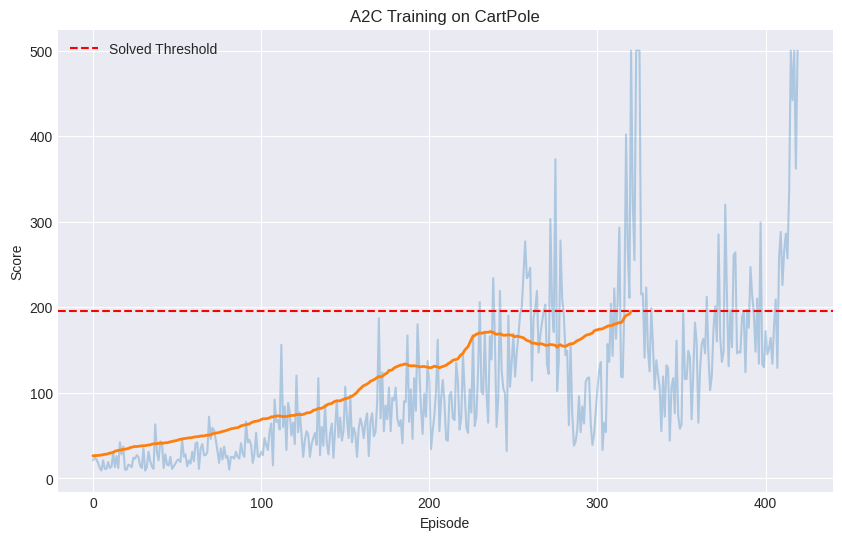

In [11]:
# train Actor-Critic agent

def train_a2c_agent(env_name='CartPole-v1', n_episodes=1000):
    """Train A2C agent on CartPole environment"""

    env = gym.make(env_name)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    agent = A2CAgent(state_dim, action_dim, lr=0.001, gamma=0.99)

    scores = []
    scores_window = deque(maxlen=100)

    for episode in range(n_episodes):
        state_tuple, info = env.reset()
        state = state_tuple
        total_reward = 0

        while True:
            action = agent.get_action(state)
            next_state_tuple, reward, terminated, truncated, info = env.step(action)
            next_state = next_state_tuple
            done = terminated or truncated

            agent.rewards.append(reward)
            state = next_state
            total_reward += reward

            if done:
                # Update the agent's network at the end of the episode
                agent.update(next_state, done)
                break

        scores.append(total_reward)
        scores_window.append(total_reward)

        if episode % 100 == 0:
            print(f'Episode {episode}, Average Score: {np.mean(scores_window):.2f}')

        if np.mean(scores_window) >= 195.0:
            print(f'\nEnvironment solved in {episode} episodes!')
            break

    env.close()
    return agent, scores

print("\nTraining A2C on CartPole...")
ac_agent, ac_scores = train_a2c_agent(n_episodes=1000)

# Plotting the A2C training curve
plt.figure(figsize=(10, 6))
plt.plot(ac_scores, alpha=0.3)
plt.plot(np.convolve(ac_scores, np.ones(100)/100, mode='valid'), linewidth=2)
plt.axhline(y=195, color='r', linestyle='--', label='Solved Threshold')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.title('A2C Training on CartPole')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
import gymnasium as gym

def visualize_ac_policy(agent, n_episodes=1):
    """Visualize trained A2C agent playing CartPole"""
    env = gym.make('CartPole-v1', render_mode='rgb_array')

    for episode in range(n_episodes):
        state_tuple, info = env.reset()
        state = state_tuple
        total_reward = 0
        frames = []

        print(f"\nEpisode {episode + 1}")

        while True:
            frame = env.render()
            frames.append(frame)

            # Get action from trained agent
            action = agent.get_action(state)

            next_state_tuple, reward, terminated, truncated, _ = env.step(action)
            next_state = next_state_tuple
            done = terminated or truncated
            total_reward += reward
            state = next_state

            if done:
                print(f"Total Reward: {total_reward}")
                break

        # Create animation
        if episode == 0:  # Only animate first episode
            fig, ax = plt.subplots(figsize=(6, 4))
            ax.axis('off')
            img = ax.imshow(frames[0])

            def update(frame):
                img.set_data(frame)
                return [img]

            anim = animation.FuncAnimation(fig, update, frames=frames[::2],
                                         interval=50, blit=True)
            plt.close()

            # Display animation
            display(HTML(anim.to_jshtml()))

    env.close()

# Visualize AC agent
visualize_ac_policy(ac_agent, n_episodes=1)


Episode 1
Total Reward: 458.0


# 11: Visualizing Learning Progress


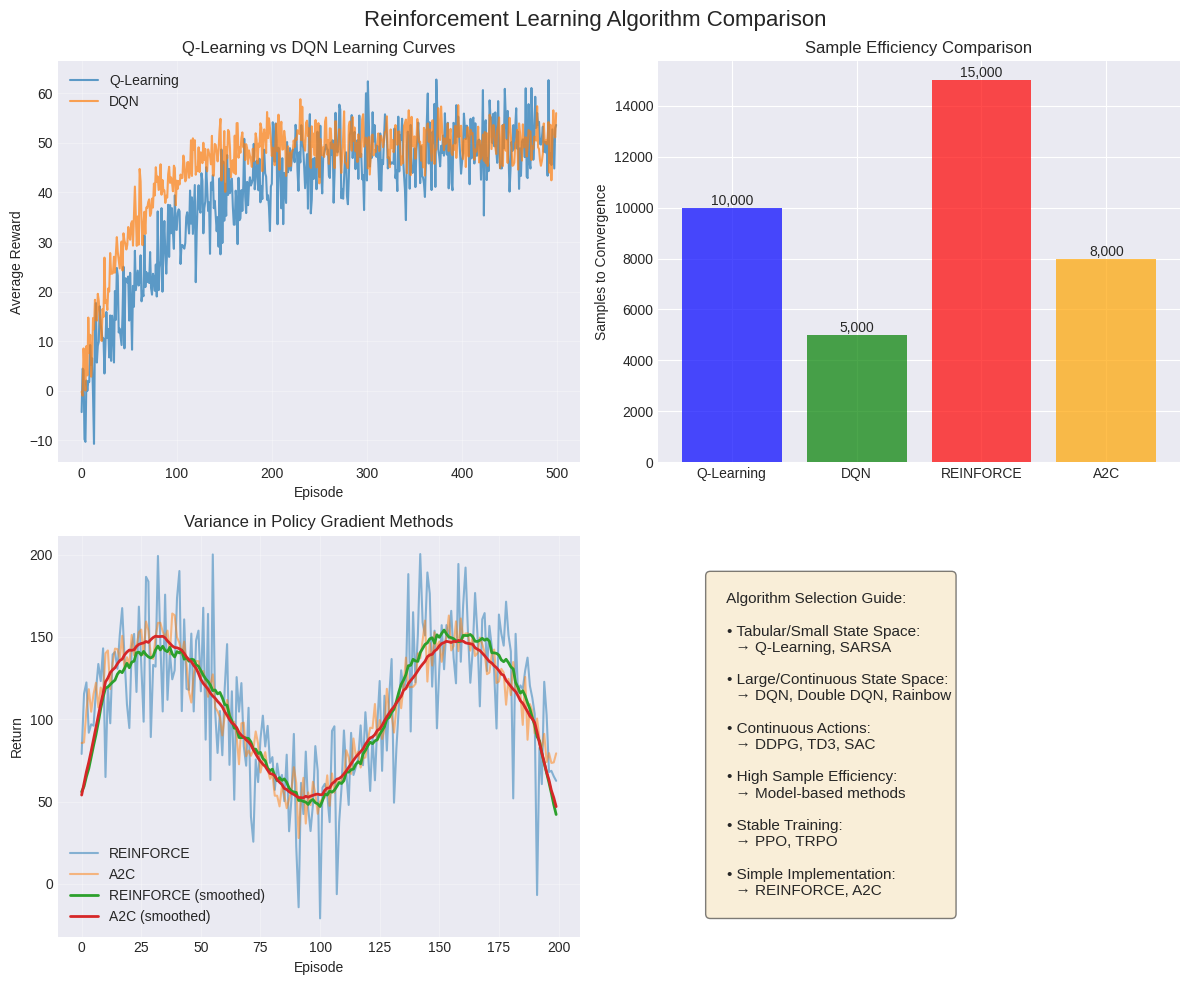

In [13]:
# Cell 13: Visualizing Learning Progress

def visualize_learning_comparison():
    """Compare learning curves of different algorithms"""

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # 1. Q-Learning vs DQN
    ax = axes[0, 0]

    # Simulated learning curves
    episodes = np.arange(0, 500)
    q_learning_curve = 50 * (1 - np.exp(-episodes / 100)) + np.random.normal(0, 5, len(episodes))
    dqn_curve = 50 * (1 - np.exp(-episodes / 50)) + np.random.normal(0, 3, len(episodes))

    ax.plot(episodes, q_learning_curve, label='Q-Learning', alpha=0.7)
    ax.plot(episodes, dqn_curve, label='DQN', alpha=0.7)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Average Reward')
    ax.set_title('Q-Learning vs DQN Learning Curves')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 2. Sample Efficiency
    ax = axes[0, 1]

    algorithms = ['Q-Learning', 'DQN', 'REINFORCE', 'A2C']
    samples_needed = [10000, 5000, 15000, 8000]
    colors = ['blue', 'green', 'red', 'orange']

    bars = ax.bar(algorithms, samples_needed, color=colors, alpha=0.7)
    ax.set_ylabel('Samples to Convergence')
    ax.set_title('Sample Efficiency Comparison')

    for bar, samples in zip(bars, samples_needed):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{samples:,}', ha='center', va='bottom')

    # 3. Stability Comparison
    ax = axes[1, 0]

    episodes = np.arange(0, 200)

    # REINFORCE (high variance)
    reinforce_returns = 100 + 50 * np.sin(episodes / 20) + np.random.normal(0, 30, len(episodes))

    # A2C (lower variance)
    a2c_returns = 100 + 50 * np.sin(episodes / 20) + np.random.normal(0, 10, len(episodes))

    ax.plot(episodes, reinforce_returns, label='REINFORCE', alpha=0.5)
    ax.plot(episodes, a2c_returns, label='A2C', alpha=0.5)
    ax.plot(episodes, np.convolve(reinforce_returns, np.ones(20)/20, mode='same'),
            label='REINFORCE (smoothed)', linewidth=2)
    ax.plot(episodes, np.convolve(a2c_returns, np.ones(20)/20, mode='same'),
            label='A2C (smoothed)', linewidth=2)

    ax.set_xlabel('Episode')
    ax.set_ylabel('Return')
    ax.set_title('Variance in Policy Gradient Methods')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 4. Algorithm Selection Guide
    ax = axes[1, 1]
    ax.axis('off')

    guide_text = """
    Algorithm Selection Guide:

    • Tabular/Small State Space:
      → Q-Learning, SARSA

    • Large/Continuous State Space:
      → DQN, Double DQN, Rainbow

    • Continuous Actions:
      → DDPG, TD3, SAC

    • High Sample Efficiency:
      → Model-based methods

    • Stable Training:
      → PPO, TRPO

    • Simple Implementation:
      → REINFORCE, A2C
    """

    ax.text(0.1, 0.9, guide_text, transform=ax.transAxes,
            fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.suptitle('Reinforcement Learning Algorithm Comparison', fontsize=16)
    plt.tight_layout()
    plt.show()

visualize_learning_comparison()

# 12: Key Takeaways


In [14]:
# Cell 15: Key Takeaways

print("\n" + "="*60)
print("KEY TAKEAWAYS")
print("="*60)

takeaways = """
1. **Tabular vs Deep RL**:
   - Tabular: Exact Q-values for each state-action pair
   - Deep: Function approximation for large/continuous spaces
   - Trade-off: Convergence guarantees vs scalability

2. **Exploration Strategies**:
   - ε-greedy: Simple but effective
   - Boltzmann: Temperature-based exploration
   - UCB: Optimism in face of uncertainty
   - Critical for discovering optimal policies

3. **Value-Based Methods**:
   - Q-Learning: Off-policy, can learn from any data
   - DQN: Handles large state spaces with neural networks
   - Experience replay and target networks for stability

4. **Policy Gradient Methods**:
   - REINFORCE: Simple but high variance
   - Actor-Critic: Reduced variance with value baseline
   - Better for continuous action spaces

5. **Key Challenges**:
   - Sample efficiency: RL requires many interactions
   - Stability: Function approximation can diverge
   - Credit assignment: Which actions led to reward?
   - Exploration: Balance with exploitation

6. **Best Practices**:
   - Start simple (tabular/linear before deep)
   - Monitor multiple metrics (not just reward)
   - Use proven tricks (replay buffer, target networks)
   - Careful hyperparameter tuning
   - Visualize learned policies/values

7. **Applications**:
   - Games (Go, Atari, StarCraft)
   - Robotics (manipulation, locomotion)
   - Resource management
   - Recommendation systems
   - Autonomous driving
"""

print(takeaways)


KEY TAKEAWAYS

1. **Tabular vs Deep RL**:
   - Tabular: Exact Q-values for each state-action pair
   - Deep: Function approximation for large/continuous spaces
   - Trade-off: Convergence guarantees vs scalability

2. **Exploration Strategies**:
   - ε-greedy: Simple but effective
   - Boltzmann: Temperature-based exploration
   - UCB: Optimism in face of uncertainty
   - Critical for discovering optimal policies

3. **Value-Based Methods**:
   - Q-Learning: Off-policy, can learn from any data
   - DQN: Handles large state spaces with neural networks
   - Experience replay and target networks for stability

4. **Policy Gradient Methods**:
   - REINFORCE: Simple but high variance
   - Actor-Critic: Reduced variance with value baseline
   - Better for continuous action spaces

5. **Key Challenges**:
   - Sample efficiency: RL requires many interactions
   - Stability: Function approximation can diverge
   - Credit assignment: Which actions led to reward?
   - Exploration: Balance with e